### Diabetes data set

#### Import libraries

In [1]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt

### Data Gathering

In [2]:
df = pd.read_csv('Diabetes Data.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,72.254807,12.115932,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [6]:
df["BloodPressure"] = df["BloodPressure"].replace({0: df["BloodPressure"].mean()})

In [8]:
X = df.drop(['Outcome'], axis = 1)
y = df['Outcome']

In [9]:
y.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

#### Split Data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                   test_size=0.20, random_state=42)

In [11]:
X_train.shape

(614, 8)

In [12]:
y_train.value_counts()

Outcome
0    401
1    213
Name: count, dtype: int64

In [54]:
df['Outcome'].unique()

array([1, 0], dtype=int64)

<Axes: xlabel='Outcome', ylabel='count'>

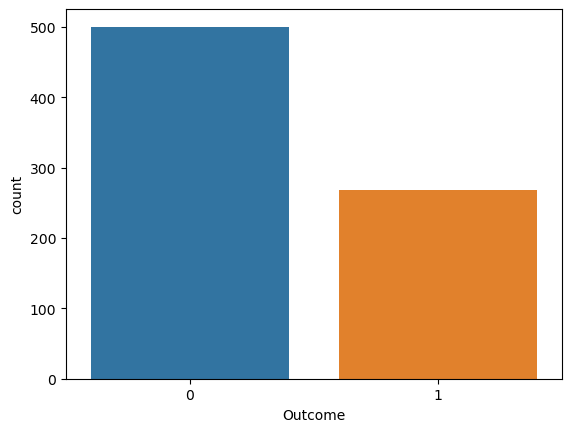

In [13]:
sns.countplot(x = df['Outcome'])

#### Build Decision Tree Model

In [15]:
dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=6)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=6)

#### Training data Accuarcy

In [16]:
y_pred_train = dt_model.predict(X_train)
y_pred_train

train_accuarcy = accuracy_score(y_train, y_pred_train)
print('Training data accuracy is : \n', train_accuarcy)

print()

clf_report = classification_report(y_train, y_pred_train)
print('Classification report :\n', clf_report)

print()

cnf_matrix = confusion_matrix(y_train, y_pred_train)
print('Confusion matrix is :\n', cnf_matrix)

Training data accuracy is : 
 0.8501628664495114

Classification report :
               precision    recall  f1-score   support

           0       0.92      0.84      0.88       401
           1       0.74      0.86      0.80       213

    accuracy                           0.85       614
   macro avg       0.83      0.85      0.84       614
weighted avg       0.86      0.85      0.85       614


Confusion matrix is :
 [[338  63]
 [ 29 184]]


In [17]:
(338+184)/614

0.8501628664495114

### Testing data Accuarcy

In [19]:
y_pred_test = dt_model.predict(X_test)
y_pred_test

test_accuarcy = accuracy_score(y_test, y_pred_test)
print('Testing data accuracy is : \n', test_accuarcy)

print()

clf_report = classification_report(y_test, y_pred_test)
print('Classification report :\n', clf_report)

print()

cnf_matrix = confusion_matrix(y_test, y_pred_test)
print('Confusion matrix is :\n', cnf_matrix)

Testing data accuracy is : 
 0.7467532467532467

Classification report :
               precision    recall  f1-score   support

           0       0.85      0.74      0.79        99
           1       0.62      0.76      0.68        55

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.77      0.75      0.75       154


Confusion matrix is :
 [[73 26]
 [13 42]]


In [20]:
y.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [21]:
y_train.value_counts()

Outcome
0    401
1    213
Name: count, dtype: int64

In [22]:
y_test.value_counts()

Outcome
0    99
1    55
Name: count, dtype: int64

### Plot Decision Tree

In [23]:
plt.figure(figsize=(200,100))
tree = plot_tree(decision_tree = dt_model, feature_names=X.columns, 
                 class_names=['0','1'], filled = True)
plt.savefig('DT_Diabetes.png')

### Hyperparameter tuning

#### 1. GridSearchCV

In [24]:
hyperparameters = {'criterion' : ['gini', 'entropy'],
                    'max_depth' : np.arange(2,10),
                    'min_samples_split' : np.arange(2,15),
                     'min_samples_leaf' : np.arange(2,16)}
dt_model = DecisionTreeClassifier()
dt_model
gscv_dt_model = GridSearchCV(dt_model, hyperparameters, cv=5)
gscv_dt_model.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': array([2, 3, 4, 5, 6, 7, 8, 9]),
                         'min_samples_leaf': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
                         'min_samples_split': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])})

In [25]:
gscv_dt_model.best_params_

{'criterion': 'gini',
 'max_depth': 7,
 'min_samples_leaf': 14,
 'min_samples_split': 2}

In [26]:
best_dt_model = DecisionTreeClassifier(max_depth=7, min_samples_leaf=14
                                      , min_samples_split=2)
best_dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7, min_samples_leaf=14)

#### Training data accuracy GridSearchCV

In [27]:
y_pred_train = best_dt_model.predict(X_train)
y_pred_train

train_accuarcy = accuracy_score(y_train, y_pred_train)
print('Training data accuracy is : \n', train_accuarcy)

print()

clf_report = classification_report(y_train, y_pred_train)
print('Classification report :\n', clf_report)

print()

cnf_matrix = confusion_matrix(y_train, y_pred_train)
print('Confusion matrix is :\n', cnf_matrix)

Training data accuracy is : 
 0.8371335504885994

Classification report :
               precision    recall  f1-score   support

           0       0.90      0.85      0.87       401
           1       0.74      0.81      0.78       213

    accuracy                           0.84       614
   macro avg       0.82      0.83      0.82       614
weighted avg       0.84      0.84      0.84       614


Confusion matrix is :
 [[341  60]
 [ 40 173]]


#### Testing data accuracy GridSearchCV

In [28]:
y_pred_test = best_dt_model.predict(X_test)
y_pred_test

test_accuarcy = accuracy_score(y_test, y_pred_test)
print('Testing data accuracy is : \n', test_accuarcy)

print()

clf_report = classification_report(y_test, y_pred_test)
print('Classification report :\n', clf_report)

print()

cnf_matrix = confusion_matrix(y_test, y_pred_test)
print('Confusion matrix is :\n', cnf_matrix)

Testing data accuracy is : 
 0.7272727272727273

Classification report :
               precision    recall  f1-score   support

           0       0.83      0.73      0.77        99
           1       0.60      0.73      0.66        55

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154


Confusion matrix is :
 [[72 27]
 [15 40]]


#### 2. Randomized Search CV

In [29]:
hyperparameters = {'criterion' : ['gini', 'entropy'],
                    'max_depth' : np.arange(2,15),
                    'min_samples_split' : np.arange(2,20),
                     'min_samples_leaf' : np.arange(2,25)}
dt_model = DecisionTreeClassifier()
dt_model
rscv_dt_model = RandomizedSearchCV(dt_model, hyperparameters, cv=5)
rscv_dt_model.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(),
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
                                        'min_samples_leaf': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24]),
                                        'min_samples_split': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19])})

In [30]:
rscv_dt_model.best_params_

{'min_samples_split': 18,
 'min_samples_leaf': 15,
 'max_depth': 10,
 'criterion': 'gini'}

In [31]:
rscv_dt_model.best_estimator_

DecisionTreeClassifier(max_depth=10, min_samples_leaf=15, min_samples_split=18)

In [33]:
best_dt_model1 = DecisionTreeClassifier(max_depth=10, min_samples_leaf=15
                                      , min_samples_split=18)
best_dt_model1.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=15, min_samples_split=18)

#### Training data accuracy RandomizedSearchCV

In [34]:
y_pred_train1 = best_dt_model1.predict(X_train)
y_pred_train1

train_accuarcy = accuracy_score(y_train, y_pred_train1)
print('Training data accuracy is : \n', train_accuarcy)

print()

clf_report = classification_report(y_train, y_pred_train1)
print('Classification report :\n', clf_report)

print()

cnf_matrix = confusion_matrix(y_train, y_pred_train1)
print('Confusion matrix is :\n', cnf_matrix)

Training data accuracy is : 
 0.8371335504885994

Classification report :
               precision    recall  f1-score   support

           0       0.90      0.85      0.87       401
           1       0.74      0.81      0.78       213

    accuracy                           0.84       614
   macro avg       0.82      0.83      0.82       614
weighted avg       0.84      0.84      0.84       614


Confusion matrix is :
 [[341  60]
 [ 40 173]]


#### Testing data accuracy RandomizedSearchCV

In [35]:
y_pred_test1 = best_dt_model1.predict(X_test)
y_pred_test1

test_accuarcy = accuracy_score(y_test, y_pred_test1)
print('Testing data accuracy is : \n', test_accuarcy)

print()

clf_report = classification_report(y_test, y_pred_test1)
print('Classification report :\n', clf_report)

print()

cnf_matrix = confusion_matrix(y_test, y_pred_test1)
print('Confusion matrix is :\n', cnf_matrix)

Testing data accuracy is : 
 0.7272727272727273

Classification report :
               precision    recall  f1-score   support

           0       0.83      0.73      0.77        99
           1       0.60      0.73      0.66        55

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154


Confusion matrix is :
 [[72 27]
 [15 40]]
